# 🤖 EfficientNetB0 Transfer Learning – staged fine-tuning

**Regression model for spherical equivalent estimation (`target_SE`) from full-preprocessed fundus images**

This notebook adapts the previous EfficientNetB0 transfer learning classification pipeline to a **regression task**.

Instead of predicting the probability of myopia, the model predicts a continuous value:

`target_SE` = spherical equivalent in diopters.

The model is trained in three stages:

1. **Stage 1:** EfficientNetB0 frozen, train only the regression head.
2. **Stage 2:** load Stage 1, unfreeze the last 20 EfficientNetB0 layers, fine-tune with lower learning rate.
3. **Stage 3:** load Stage 2, unfreeze the last 40 EfficientNetB0 layers, fine-tune with even lower learning rate.
4. **Stage 4:** load Stage 3, unfreeze the last 60 EfficientNetB0 layers, fine-tune with a very small learning rate.
5. **Stage 5:** load Stage 4, unfreeze the last 80 EfficientNetB0 layers, fine-tune cautiously with a very small learning rate.


-> Stage 1 es el modelo más “puro” de transfer learning: EfficientNetB0 está congelado y solo se entrena la cabeza nueva de clasificación/regresión. Es decir, se usa EfficientNetB0 como extractor fijo de características.

Stage 2-5 son pruebas de fine-tuning: se carga el modelo anterior, se descongela parte de EfficientNetB0 y se deja que algunas capas finales también aprendan con nuestras imágenes de retina.

## 🧠 0. Changes from classification to regression:

Main changes:

| Classification | Regression |
|---|---|
| Target: `class_label` | Target: `target_SE` |
| Output: `Dense(1, sigmoid)` | Output: `Dense(1, linear)` |
| Loss: Binary Focal Crossentropy | Loss: MSE by default |
| Metrics: AUC, accuracy, AP, recall | Metrics: MAE, RMSE, R² |
| EarlyStopping on `val_auc` | EarlyStopping on `val_mae` |
| Curves: ROC / PR / Confusion matrix | Curves: prediction scatter / residuals |

EfficientNetB0 is still used as a pretrained feature extractor, but the final head now learns to estimate a numerical refractive error instead of a class probability.

This notebook evaluates **EfficientNetB0 transfer learning for SE regression** using the **FullPreproc** image set. It is the regression counterpart of the previous EfficientNetB0 classification notebook.

This comparison is especially useful because EfficientNetB0 improved classification ranking quite clearly compared with the earlier small CNN and ResNet models. Therefore, the key question here is whether the same pretrained visual features can also help with the harder continuous task: predicting **SE** directly.

The most important point is to evaluate the model against the **mean baseline**. In the previous regression notebooks, most models produced **R² values around 0** and predictions collapsed near the mean SE. Here, the interesting question is whether transfer learning produces a real positive R² or simply repeats that same mean-prediction behaviour.


## ⚙️ 1. Imports and reproducibility


In [1]:
from __future__ import annotations

#import argparse - not needed
import importlib
import sys
from pathlib import Path
from types import SimpleNamespace #extra addition
from typing import Any

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
#from sklearn.model_selection import train_test_split - we import now
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt #extra addition

#extra addition ----------------------------------------
SEED = 42 #
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception as e:
    print("Determinism could not be enabled:", e)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


## 🧾 2. Experiment configuration

These values can be adapteed if a different experiment is wanted (adapting the number of epochs, batch size...)

The notebook reads most paths from `config.yaml`.

For this notebook:
- `EXPERIMENT = "full_preproc"`
- images are taken from the full preprocessing table
- splits are taken from the regression split folder
- models are saved in the same full-preprocessing model output folder, using regression-specific names

Important detail: this EfficientNetB0 implementation keeps images in the **0–255 pixel range**. This is different from some of the previous notebooks where images were converted to **0–1**.


In [2]:
# Experiment selected in config.yaml
EXPERIMENT = "full_preproc"

# Model/loss settings
HEAD = "mlp"
EFFICIENTNET_WEIGHTS = "imagenet"

# Regression loss: "mse" for direct comparability with many regression models
# Might this to "huber" if training is unstable or very affected by outliers
REGRESSION_LOSS = "mse"
HUBER_DELTA = 1.0

# Training settings - extra addition (#)
EPOCHS = 50 #
BATCH_SIZE_OVERRIDE = 16 # - Use None to read batch size from config.yaml
BASE_LEARNING_RATE = 1e-4 #
EARLY_STOPPING_PATIENCE = 5 #
REDUCE_LR_PATIENCE = 5 #
VERBOSE = 2 #

# Optional: force a project root manually if automatic detection fails.
# Example: PROJECT_ROOT_OVERRIDE = r"C:/Users/Paula/Desktop/TFG_Biomed"
PROJECT_ROOT_OVERRIDE = None # Extra addition

STAGES = [
    {
        "stage": 1,
        "name": "stage1_frozen",
        "unfreeze_last_n_layers": 0,
        "lr_multiplier": 1.0,
    },
    {
        "stage": 2,
        "name": "stage2_unfreeze20",
        "unfreeze_last_n_layers": 20,
        "lr_multiplier": 0.1,
    },
    {
        "stage": 3,
        "name": "stage3_unfreeze40",
        "unfreeze_last_n_layers": 40,
        "lr_multiplier": 0.01,
    },
    {
        "stage": 4,
        "name": "stage4_unfreeze60",
        "unfreeze_last_n_layers": 60,
        "lr_multiplier": 0.005,
    },
    {
        "stage": 5,
        "name": "stage5_unfreeze80",
        "unfreeze_last_n_layers": 80,
        "lr_multiplier": 0.002,
    },
]

#extra addition
args = SimpleNamespace(
    epochs=EPOCHS,
    batch_size=BATCH_SIZE_OVERRIDE,
    learning_rate=BASE_LEARNING_RATE,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    reduce_lr_patience=REDUCE_LR_PATIENCE,
    verbose=VERBOSE,
)


## 📁 3. Project paths

This cell searches for `config.yaml` and imports the helper functions from `src.paths`.

The notebook should be run from inside the project folder, or if failing, set `PROJECT_ROOT_OVERRIDE` in the previous cell.


In [3]:
def find_project_root(start: Path | None = None) -> Path: #extra addition: fixed for congif.yaml possible failure
    if PROJECT_ROOT_OVERRIDE is not None: 
        root = Path(PROJECT_ROOT_OVERRIDE).expanduser().resolve()
        if not (root / "config.yaml").exists():
            raise FileNotFoundError(f"config.yaml was not found in PROJECT_ROOT_OVERRIDE: {root}")
        return root

    root = (start or Path.cwd()).resolve()
    while not (root / "config.yaml").exists():
        if root == root.parent:
            raise FileNotFoundError(
                "config.yaml was not found. Run this notebook from inside the project "
                "or set PROJECT_ROOT_OVERRIDE in the configuration cell."
            )
        root = root.parent
    return root

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

importlib.invalidate_caches()

from src.paths import (  # noqa: E402
    get_experiment_paths,
    get_paths,
    load_config,
    validate_experiment_paths,
    validate_main_structure,
)

In [4]:
# parse_args function would be here, but I believe there is no longer need for it
def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="Train only the FullPreproc binary myopia classification model."
    )
    parser.add_argument("--epochs", type=int, default=10)
    parser.add_argument("--batch-size", type=int, default=None)
    parser.add_argument("--learning-rate", type=float, default=1e-4)
    parser.add_argument(
        "--early-stopping-patience",
        type=int,
        default=15,
        help="Epochs without val_auc improvement before stopping training.",
    )
    parser.add_argument(
        "--reduce-lr-patience",
        type=int,
        default=5,
        help="Epochs without val_auc improvement before reducing the learning rate.",
    )
    parser.add_argument(
        "--verbose",
        type=int,
        choices=[0, 1, 2],
        default=1,
        help="Keras console verbosity: 0=silent, 1=progress bar, 2=one line per epoch.",
    )
    return parser.parse_args()


In [5]:
# These are extra additions to read variables from config.yaml

cfg = load_config(PROJECT_ROOT / "config.yaml")
paths = get_paths(cfg)
validate_main_structure(paths)

exp_paths = get_experiment_paths(cfg, EXPERIMENT)
validate_experiment_paths(exp_paths)

seed = int(cfg["settings"].get("seed", SEED))
image_size = tuple(cfg["settings"]["image_size"])
batch_size = args.batch_size or int(cfg["settings"]["batch_size"])

TABLE_PATH = exp_paths["table"]

# Regression splits
if "split_regression" in exp_paths:
    SPLIT_DIR = exp_paths["split_regression"]
else:
    raise KeyError(
        "exp_paths does not contain 'split_regression'. "
        "Check src/paths.py or config.yaml. You need a regression split folder."
    )

MODELS_DIR = exp_paths["models_experiment"] #from yaml
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Experiment:", EXPERIMENT)
print("Table path:", TABLE_PATH)
print("Regression splits:", SPLIT_DIR)
print("Models output:", MODELS_DIR)
print("Image size:", image_size)
print("Batch size:", batch_size)
print("Seed:", seed)

Project root: C:\Users\paula\0B_TFGBiomed_Exe
Experiment: full_preproc
Table path: C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\Tabla_MatchImagenesConDatosClinicos_FullPreproc.xlsx
Regression splits: C:\Users\paula\0B_TFGBiomed_Exe\Splits\Regression\FullPreproc
Models output: C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\WithDropout\FullPreproc
Image size: (224, 224)
Batch size: 16
Seed: 42


## 🧹 4. Load and clean the matched table

The table is expected to contain at least these columns:

- `image_path`
- `filename`
- `patient_id`

For regression, the required target column is `target_SE`.


In [6]:
def resolve_project_path(path: str | Path) -> Path:
    path = Path(path)
    if path.is_absolute():
        return path
    return PROJECT_ROOT / path

def resolve_project_path_str(path: str | Path) -> str:
    return str(resolve_project_path(path))

def load_and_clean_table(table_path: Path) -> pd.DataFrame:
    df = pd.read_excel(table_path)

    #extra addition:
    required_cols = {"image_path", "filename", "patient_id", "target_SE"}
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(f"Missing required columns in matched table: {missing_cols}")

    df = df[df["image_path"].notna()].copy()
    df = df[df["target_SE"].notna()].copy()

    df["image_path"] = df["image_path"].astype(str)
    df["filename"] = df["filename"].astype(str)
    df["patient_id"] = df["patient_id"].astype(str).str.upper().str.strip()
    df["target_SE"] = pd.to_numeric(df["target_SE"], errors="coerce")

    df = df.dropna(subset=["image_path", "filename", "patient_id", "target_SE"]).copy()
    df["target_SE"] = df["target_SE"].astype("float32")

    missing_paths = df["image_path"].apply(lambda p: not resolve_project_path(p).exists()).sum()
    if missing_paths:
        raise FileNotFoundError(
            f"{missing_paths} image paths from the match table do not exist. "
            "Check whether image_path values are relative to PROJECT_ROOT."
        )

    return df

#extra addition: loading the table into a df to show it
df = load_and_clean_table(TABLE_PATH)

print("Total valid images:", len(df))
print("Patients:", df["patient_id"].nunique())
print("target_SE summary:")
display(df["target_SE"].describe())
display(df.head())

Total valid images: 2126
Patients: 1061
target_SE summary:


count    2126.000000
mean        0.021696
std         2.109061
min       -20.375000
25%        -0.250000
50%         0.000000
75%         0.750000
max         9.000000
Name: target_SE, dtype: float64

,image_path,filename,patient_id,image_date_raw,image_date,modality,eye,nhc,FechaNacimiento,Edad,...,¿Revisar?,Ultimavisita_dt,match_type,target_SE,class_label,original_image_path,preprocessing,image_size,clahe_applied,clahe_mode
0,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6138_17092024_165654_Color_R_001.jpg,A6138,17092024,2024-09-17,Color,R,A6138,2020-06-03,6,...,SI,2024-09-17,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance
1,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6138_17092024_165721_Color_L_001.jpg,A6138,17092024,2024-09-17,Color,L,A6138,2020-06-03,6,...,SI,2024-09-17,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance
2,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6140_11122023_191157_IR_R_001.jpg,A6140,11122023,2023-12-11,IR,R,A6140,1975-10-06,51,...,NO,2023-12-11,id+date,-2.250,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance
3,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6140_11122023_191221_IR_L_001.jpg,A6140,11122023,2023-12-11,IR,L,A6140,1975-10-06,51,...,NO,2023-12-11,id+date,-0.625,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance
4,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6142_12042023_153339_Color_R_001.jpg,A6142,12042023,2023-04-12,Color,R,A6142,2000-07-08,26,...,NO,2023-04-12,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance


The notebook uses **2,126 valid images** from **1,061 patients**, using the FullPreproc image set. The target variable is **SE**, with a mean close to zero (**0.022 D**) and a median of **0 D**.

The distribution is highly concentrated around emmetropic or near-emmetropic values, but also contains extreme values, from approximately **-20.38 D** to **+9.00 D**. This creates a difficult regression problem: a model can obtain a moderate MAE by predicting values near zero, while still failing to capture the more clinically relevant extremes.

This is why R², RMSE and predicted-vs-true plots are essential. MAE alone can be misleading here because the dataset is strongly centred around **SE = 0 D**.


## ✂️ 5. Patient-level train/validation/test splits

This notebook loads the patient-level regression splits created in 
00_CreatePatientLevelSplits_Classf_Regrss.ipynb.

It does not create new splits.

In [7]:
# Load and validate existing patient-level regression splits created in 00_CreatePatientLevelSplits_Classf_Regrss.ipynb

def load_existing_splits(split_dir: Path) -> dict[str, pd.DataFrame]:
    split_files = {
        name: split_dir / f"{name}.csv"
        for name in ["train", "val", "test"]
    }

    for split_name, split_path in split_files.items():
        if not split_path.exists():
            raise FileNotFoundError(
                f"Missing {split_name} split file: {split_path}. "
                "Run 00_CreatePatientLevelSplits_Classf_Regrss.ipynb first."
            )

    return {
        split_name: pd.read_csv(split_path)
        for split_name, split_path in split_files.items()
    }


def assert_no_overlap(split_dfs: dict[str, pd.DataFrame], column: str, name: str) -> None:
    split_sets = {
        split_name: set(split_df[column].astype(str))
        for split_name, split_df in split_dfs.items()
    }

    pairs = [("train", "val"), ("train", "test"), ("val", "test")]

    for left, right in pairs:
        overlap = split_sets[left] & split_sets[right]
        if overlap:
            raise AssertionError(
                f"{name} leakage detected between {left} and {right}: "
                f"{len(overlap)} overlapping values. Example: {list(overlap)[:5]}"
            )

    print(f"OK: no {name} overlap across train/val/test.")


def validate_regression_splits(split_dfs: dict[str, pd.DataFrame]) -> None:
    required_cols = {"image_path", "patient_id", "target_SE"}

    for split_name, split_df in split_dfs.items():
        missing_cols = required_cols - set(split_df.columns)
        if missing_cols:
            raise ValueError(f"{split_name} split is missing columns: {missing_cols}")

        split_df["target_SE"] = pd.to_numeric(split_df["target_SE"], errors="coerce")

        if split_df["target_SE"].isna().any():
            raise ValueError(f"{split_name} split contains NaN values in target_SE.")

        print(
            f"{split_name}: {len(split_df)} images, "
            f"{split_df['patient_id'].nunique()} patients"
        )

    assert_no_overlap(split_dfs, "patient_id", "patient")
    assert_no_overlap(split_dfs, "image_path", "image")

    print("\ntarget_SE summary by split:")
    for split_name, split_df in split_dfs.items():
        print(f"\n{split_name}")
        print(split_df["target_SE"].describe())


split_dfs = load_existing_splits(SPLIT_DIR)
validate_regression_splits(split_dfs)

train: 1700 images, 848 patients
val: 209 images, 106 patients
test: 217 images, 107 patients
OK: no patient overlap across train/val/test.
OK: no image overlap across train/val/test.

target_SE summary by split:

train
count    1700.000000
mean        0.006029
std         2.173365
min       -20.375000
25%        -0.250000
50%         0.000000
75%         0.625000
max         7.750000
Name: target_SE, dtype: float64

val
count    209.000000
mean       0.069976
std        1.860834
min      -14.000000
25%       -0.375000
50%        0.000000
75%        0.750000
max        5.000000
Name: target_SE, dtype: float64

test
count    217.000000
mean       0.097926
std        1.806159
min       -6.500000
25%       -0.250000
50%        0.000000
75%        0.750000
max        9.000000
Name: target_SE, dtype: float64


The regression split contains **1,700 training images**, **209 validation images** and **217 test images**. The checks confirm that there is **no patient overlap** and **no image overlap** between the train, validation and test sets.

This is important because several images may come from the same patient. If the same patient appeared in both training and test sets, the regression evaluation could be artificially optimistic. Since this is avoided, the test results are more reliable.

The SE distribution is similar across splits, although the training set contains the most extreme negative value (**-20.375 D**) and the test set contains the most extreme positive value (**+9.0 D**). These extremes are important when interpreting RMSE and R², because errors on extreme values have a larger influence on those metrics.


## 🧮 6. TensorFlow datasets

This dataloader reads image paths from the regression split CSV files and uses `target_SE` as a continuous label.

Unlike previous notebooks where images were converted to `[0, 1]`, here images are only cast to `float32`, keeping their values in the `[0, 255]` range before entering EfficientNetB0.


In [8]:
def make_datasets(
    split_dir: Path,
    image_size: tuple[int, int],
    batch_size: int,
    seed: int,
) -> tuple[tf.data.Dataset, tf.data.Dataset, tf.data.Dataset]:
    autotune = tf.data.AUTOTUNE
    shuffle_buffer_size = 2048

    augment = keras.Sequential( #extra: augmentations before decode_img
        [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.02),
            layers.RandomZoom(0.05),
        ],
        name="light_augmentation",
    )

    def decode_img(path, y):
        img_bytes = tf.io.read_file(path)
        img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
        img = tf.ensure_shape(img, [None, None, 3])
        img = tf.image.resize(img, image_size, method="bilinear")
        img = tf.cast(img, tf.float32)  # Keep pixel range 0-255 for EfficientNetB0
        return img, tf.cast(y, tf.float32)

    def make_regression_ds(csv_path: Path, training: bool = False) -> tf.data.Dataset:
        df_split = pd.read_csv(csv_path)
        paths = df_split["image_path"].map(resolve_project_path_str).astype(str).values
        targets = df_split["target_SE"].astype("float32").values

        ds = tf.data.Dataset.from_tensor_slices((paths, targets))
        ds = ds.map(decode_img, num_parallel_calls=autotune)

        if training:
            ds = ds.shuffle(
                shuffle_buffer_size,
                seed=seed,
                reshuffle_each_iteration=True,
            )
            ds = ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=autotune)

        return ds.batch(batch_size).prefetch(autotune)

    return (
        make_regression_ds(split_dir / "train.csv", training=True),
        make_regression_ds(split_dir / "val.csv", training=False),
        make_regression_ds(split_dir / "test.csv", training=False),
    )

#extra: splitting here and now...
train_ds, val_ds, test_ds = make_datasets(
    split_dir=SPLIT_DIR,
    image_size=image_size,
    batch_size=batch_size,
    seed=seed,
)

#... and checking performance before moving on
for xb, yb in train_ds.take(1):
    print("Batch image shape:", xb.shape)
    print("Batch label shape:", yb.shape)
    print("Pixel range in batch:", float(tf.reduce_min(xb)), "to", float(tf.reduce_max(xb)))


Batch image shape: (16, 224, 224, 3)
Batch label shape: (16,)
Pixel range in batch: 0.0 to 255.0


Technical note: pixel range and EfficientNetB0 preprocessing

The batch inspection shows images with shape **224×224×3** and pixel values in the **0–255 range**.

This differs from the small CNN regression notebooks, where inputs were usually normalized to **0–1**. Here, this is acceptable because the EfficientNetB0 pipeline is designed around its own preprocessing conventions.

Therefore, comparisons with previous notebooks should be interpreted as comparisons between complete modelling pipelines, not only between architectures. The input preprocessing, backbone and regression head are all part of the final model behaviour.


## 🧩 7. EfficientNetB0 model definition

The model uses **EfficientNetB0 without its original ImageNet head**, followed by a custom regression head:

`GlobalAveragePooling2D → BatchNormalization → Dense(256) → Dropout(0.4) → Dense(64) → Dropout(0.2) → Dense(1, linear)`

Stage 1 keeps EfficientNetB0 frozen and trains only the regression head. Stages 2–5 progressively unfreeze the last **20, 40, 60 and 80 layers**, using smaller learning rates.

Compared with the previous small CNN regression models, this architecture is much more powerful and benefits from pretrained visual features. Compared with the ResNet notebook, the key difference is that EfficientNetB0 is pretrained, whereas the ResNet model was trained from scratch. This distinction matters because the ResNet regression model obtained a negative R², while this model later reaches a clearly positive R².


In [9]:
def configure_efficientnet_base_trainability( #switching this function to top of cell bc function below uses it (no need, but maked more sense "chronologically")
    base_model: keras.Model,
    unfreeze_last_n_layers: int,
) -> None:
    if unfreeze_last_n_layers < 0:
        raise ValueError("unfreeze_last_n_layers must be >= 0.")

    base_model.trainable = bool(unfreeze_last_n_layers)

    # Freeze everything first
    for layer in base_model.layers:
        layer.trainable = False

    if not unfreeze_last_n_layers:
        return

    # BatchNorm layers are kept frozen during fine-tuning for stability
    trainable_layers = [
        layer
        for layer in base_model.layers
        if not isinstance(layer, layers.BatchNormalization)
    ]

    for layer in trainable_layers[-unfreeze_last_n_layers:]:
        layer.trainable = True

def build_efficientnetb0_regression(
    input_shape: tuple[int, int, int],
    unfreeze_last_n_layers: int,
) -> keras.Model:
    if unfreeze_last_n_layers < 0:
        raise ValueError("unfreeze_last_n_layers must be >= 0.")

    base_model = keras.applications.EfficientNetB0(
        include_top=False,
        weights=EFFICIENTNET_WEIGHTS,
        input_shape=input_shape,
    )
    configure_efficientnet_base_trainability(base_model, unfreeze_last_n_layers)

    inputs = keras.Input(shape=input_shape)
    features = base_model(inputs, training=bool(unfreeze_last_n_layers))
    x = layers.GlobalAveragePooling2D()(features)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation="linear")(x)

    return keras.Model(inputs, outputs, name="efficientnetb0_regression")

def find_efficientnet_base(model: keras.Model) -> keras.Model | None:
    for layer in model.layers:
        if isinstance(layer, keras.Model) and layer.name.startswith("efficientnet"):
            return layer
    return None


def configure_loaded_model_for_fine_tuning(
    model: keras.Model,
    unfreeze_last_n_layers: int,
) -> None:
    base_model = find_efficientnet_base(model)
    if base_model is None:
        raise ValueError(
            "The loaded model does not contain an EfficientNet base. "
            "Check the previous stage model path."
        )
    configure_efficientnet_base_trainability(base_model, unfreeze_last_n_layers)


def count_trainable_base_layers(model: keras.Model) -> int | None:
    base_model = find_efficientnet_base(model)
    if base_model is None:
        return None
    return sum(
        1
        for layer in base_model.layers
        if layer.trainable and not isinstance(layer, layers.BatchNormalization)
    )


## 🎯 8. Loss, optimizer, callbacks and metrics


In [10]:
def build_loss() -> keras.losses.Loss | str:
    if REGRESSION_LOSS.lower() == "mse":
        return "mse"
    if REGRESSION_LOSS.lower() == "huber":
        return keras.losses.Huber(delta=HUBER_DELTA)
    raise ValueError("REGRESSION_LOSS must be 'mse' or 'huber'.")


def compile_model(model: keras.Model, learning_rate: float) -> None:
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate),
        loss=build_loss(),
        metrics=[
            keras.metrics.MeanAbsoluteError(name="mae"),
            keras.metrics.MeanSquaredError(name="mse"),
            keras.metrics.RootMeanSquaredError(name="rmse"),
        ],
    )

#Extra: moving this function up here (makes sense chronologically)
class EpochConsoleLogger(keras.callbacks.Callback):
    def on_epoch_end(self, epoch: int, logs: dict[str, Any] | None = None) -> None:
        logs = logs or {}
        lr = float(keras.backend.get_value(self.model.optimizer.learning_rate))
        metric_names = ["loss", "mae", "rmse", "val_loss", "val_mae", "val_rmse"]
        metrics = []

        for name in metric_names:
            if name in logs:
                metrics.append(f"{name}={float(logs[name]):.6f}")

        metrics.append(f"lr={lr:.2e}")
        print(f"Epoch {epoch + 1}: " + " | ".join(metrics), flush=True)


def make_callbacks(args: SimpleNamespace) -> list[keras.callbacks.Callback]:
    return [
        EpochConsoleLogger(),
        keras.callbacks.EarlyStopping(
            monitor="val_mae",
            mode="min",
            patience=args.early_stopping_patience,
            restore_best_weights=True,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_mae",
            mode="min",
            factor=0.3,
            patience=args.reduce_lr_patience,
        ),
    ]


## 📊 9. Evaluation helpers

For regression we evaluate:
- MAE
- MSE
- RMSE
- R²
- Baseline comparison against predicting the training-set mean


In [11]:
def collect_regression_preds(
    model: keras.Model,
    ds: tf.data.Dataset,
) -> tuple[np.ndarray, np.ndarray]:
    y_true, y_pred = [], []

    for xb, yb in ds:
        p = model.predict(xb, verbose=0).ravel()
        y_true.extend(yb.numpy().ravel().tolist())
        y_pred.extend(p.tolist())

    return np.array(y_true).astype(float), np.array(y_pred).astype(float)

def get_split_targets(split_dir: Path, split_name: str) -> np.ndarray:
    split_df = pd.read_csv(split_dir / f"{split_name}.csv")
    return split_df["target_SE"].astype(float).values

def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "mse": float(mse),
        "rmse": rmse,
        "r2": float(r2_score(y_true, y_pred)),
    }

def evaluate_regression(
    model: keras.Model,
    test_ds: tf.data.Dataset,
    split_dir: Path,
) -> dict[str, Any]:
    y_true, y_pred = collect_regression_preds(model, test_ds)

    test_metrics = regression_metrics(y_true, y_pred)

    y_train = get_split_targets(split_dir, "train")
    baseline_value = float(np.mean(y_train))
    baseline_pred = np.full_like(y_true, baseline_value, dtype=float)
    baseline_metrics = regression_metrics(y_true, baseline_pred)

    residuals = y_true - y_pred

    print("Regression metrics:")
    print(f"MAE:  {test_metrics['mae']:.6f}")
    print(f"MSE:  {test_metrics['mse']:.6f}")
    print(f"RMSE: {test_metrics['rmse']:.6f}")
    print(f"R²:   {test_metrics['r2']:.6f}")

    print("\nBaseline: predict train mean")
    print(f"Train mean target_SE: {baseline_value:.6f}")
    print(f"Baseline MAE:  {baseline_metrics['mae']:.6f}")
    print(f"Baseline RMSE: {baseline_metrics['rmse']:.6f}")
    print(f"Baseline R²:   {baseline_metrics['r2']:.6f}")

    return {  #now regression
        **test_metrics,
        "baseline_train_mean": baseline_value,
        "baseline_mae": baseline_metrics["mae"],
        "baseline_mse": baseline_metrics["mse"],
        "baseline_rmse": baseline_metrics["rmse"],
        "baseline_r2": baseline_metrics["r2"],
        "y_true": y_true.tolist(),
        "y_pred": y_pred.tolist(),
        "residuals": residuals.tolist(),
    }

## 💾 10. Output paths and stage training function


In [12]:
#extra addition: one route per stage (per model)
def stage_output_paths(models_dir: Path, stage: dict[str, Any]) -> tuple[Path, Path, Path]:
    stem = f"transfer_learning_classification_with_dropout_fullpreproc_{stage['name']}"
    
    stage_model_path = models_dir / f"{stem}.keras"
    stage_summary_path = models_dir / f"{stem}_summary.json"
    stage_preds_path = models_dir / f"{stem}_predictions.csv"
    
    return stage_model_path, stage_summary_path, stage_preds_path
    
def train_stage( #extra: moved here for chr. sense
    stage: dict[str, Any],
    args: SimpleNamespace,
    input_shape: tuple[int, int, int],
    train_ds: tf.data.Dataset,
    val_ds: tf.data.Dataset,
    test_ds: tf.data.Dataset,
    split_dir: Path,
    models_dir: Path,
    previous_model_path: Path | None,
    common_summary: dict[str, Any],
) -> tuple[dict[str, Any], dict[str, list[float]]]:
    stage_model_path, stage_summary_path, stage_preds_path = stage_output_paths(models_dir, stage)    
    stage_lr = args.learning_rate * float(stage["lr_multiplier"])
    unfreeze_last_n_layers = int(stage["unfreeze_last_n_layers"])

    print("\n" + "=" * 72)
    print(f"Stage {stage['stage']}: {stage['name']}")
    print("Initial model:", previous_model_path)
    print("Unfreeze last N EfficientNetB0 layers:", unfreeze_last_n_layers)
    print("Learning rate:", stage_lr)
    print("Epochs requested:", args.epochs)
    print("=" * 72)

    if previous_model_path is None:
        model = build_efficientnetb0_regression(
            input_shape=input_shape,
            unfreeze_last_n_layers=unfreeze_last_n_layers,
        )
    else:
        model = keras.models.load_model(previous_model_path, compile=False)
        configure_loaded_model_for_fine_tuning(
            model=model,
            unfreeze_last_n_layers=unfreeze_last_n_layers,
        )

    trainable_base_layers = count_trainable_base_layers(model)
    print("EfficientNetB0 trainable base layers:", trainable_base_layers)

    compile_model(model, stage_lr)
    model.summary()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=args.epochs,
        callbacks=make_callbacks(args),
        verbose=args.verbose,
    )

    print("Keras test metrics:")
    keras_metrics = model.evaluate(test_ds, return_dict=True)
    print(keras_metrics)

    eval_metrics = evaluate_regression(
        model=model,
        test_ds=test_ds,
        split_dir=split_dir,
    )
    
    preds_df = pd.DataFrame({ #extra: for later (possibility for saving below as well)
        "y_true": eval_metrics["y_true"],
        "y_pred": eval_metrics["y_pred"],
        "residual": eval_metrics["residuals"],
    })
    # preds_df.to_csv(stage_preds_path, index=False)
    # print("Stage predictions saved at:", stage_preds_path)

    model.save(stage_model_path)
    print("Stage model saved at:", stage_model_path)

    stage_summary = {
        **common_summary,
        "stage": stage["stage"],
        "stage_name": stage["name"],
        "model_path": str(stage_model_path),
        "predictions_path": str(stage_preds_path),
        "initial_model_path": str(previous_model_path) if previous_model_path else None,
        "learning_rate": stage_lr,
        "base_learning_rate": args.learning_rate,
        "lr_multiplier": float(stage["lr_multiplier"]),
        "unfreeze_last_n_layers": unfreeze_last_n_layers,
        "trainable_base_layers": trainable_base_layers,
        "epochs_requested": args.epochs,
        "epochs_run": len(history.history.get("loss", [])),
        "best_val_mae": float(np.min(history.history.get("val_mae", [np.nan]))),
        "best_val_rmse": float(np.min(history.history.get("val_rmse", [np.nan]))),
        "keras_test_metrics": {k: float(v) for k, v in keras_metrics.items()},
        "evaluation": eval_metrics,
    }

    
    return stage_summary, history.history #returnign history as well for plotting


## 🚀 11. Run the five training stages

This cell trains the full staged pipeline (what would've been the "main function").  
Each stage loads the previous model, recompiles it with its own learning rate, trains, evaluates and saves outputs.


In [13]:
input_shape = (*image_size, 3)

common_summary = {
    "table_path": str(TABLE_PATH),
    "split_dir": str(SPLIT_DIR),
    "experiment": EXPERIMENT,
    "task": "regression",
    "target": "target_SE",
    "image_size": list(image_size),
    "batch_size": batch_size,
    "seed": seed,
    "architecture": "efficientnetb0",
    "head": HEAD,
    "efficientnet_weights": EFFICIENTNET_WEIGHTS,
    "image_pixel_range": "0-255",
    "loss": REGRESSION_LOSS,
    "huber_delta": HUBER_DELTA if REGRESSION_LOSS.lower() == "huber" else None,
}

stage_summaries = []
stage_histories = {}
previous_model_path = None

for stage in STAGES:
    stage_summary, stage_history = train_stage(
        stage=stage,
        args=args,
        input_shape=input_shape,
        train_ds=train_ds,
        val_ds=val_ds,
        test_ds=test_ds,
        split_dir=SPLIT_DIR,
        models_dir=MODELS_DIR,
        previous_model_path=previous_model_path,
        common_summary=common_summary,
    )

    stage_summaries.append(stage_summary)
    stage_histories[stage["name"]] = stage_history
    previous_model_path = Path(stage_summary["model_path"])

global_summary = {
    **common_summary,
    "base_learning_rate": args.learning_rate,
    "epochs_requested_per_stage": args.epochs,
    "stages": stage_summaries,
}




Stage 1: stage1_frozen
Initial model: None
Unfreeze last N EfficientNetB0 layers: 0
Learning rate: 0.0001
Epochs requested: 50
EfficientNetB0 trainable base layers: 0


Model: "efficientnetb0_regression"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,399,140 (16.78 MB)

 Trainable params: 347,009 (1.32 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,399,140 (16.78 MB)

 Trainable params: 3,796,149 (14.48 MB)

 Non-trainable params: 602,991 (2.30 MB)

Epoch 1/50
Epoch 1: loss=3.980279 | mae=1.371648 | rmse=1.995064 | val_loss=2.465695 | val_mae=1.012255 | val_rmse=1.570253 | lr=2.00e-07
107/107 - 146s - 1s/step - loss: 3.9803 - mae: 1.3716 - mse: 3.9803 - rmse: 1.9951 - val_loss: 2.4657 - val_mae: 1.0123 - val_mse: 2.4657 - val_rmse: 1.5703 - learning_rate: 2.0000e-07
Epoch 2/50
Epoch 2: loss=4.030982 | mae=1.397657 | rmse=2.007730 | val_loss=2.461016 | val_mae=1.012727 | val_rmse=1.568763 | lr=2.00e-07
107/107 - 108s - 1s/step - loss: 4.0310 - mae: 1.3977 - mse: 4.0310 - rmse: 2.0077 - val_loss: 2.4610 - val_mae: 1.0127 - val_mse: 2.4610 - val_rmse: 1.5688 - learning_rate: 2.0000e-07
Epoch 3/50
Epoch 3: loss=3.944966 | mae=1.353887 | rmse=1.986194 | val_loss=2.457673 | val_mae=1.013616 | val_rmse=1.567697 | lr=2.00e-07
107/107 - 115s - 1s/step - loss: 3.9450 - mae: 1.3539 - mse: 3.9450 - rmse: 1.9862 - val_loss: 2.4577 - val_mae: 1.0136 - val_mse: 2.4577 - val_rmse: 1.5677 - learning_rate: 2.0000e-07
Epoch 4/50
Epoch 4: loss=3.8030

Across the five stages, validation MAE remains close to **1.0 D**, while validation RMSE stays around **1.53–1.56 D**. The curves do not show a large improvement after Stage 1, which suggests that most of the useful information is already extracted by the frozen EfficientNetB0 features.

Fine-tuning progressively more EfficientNetB0 layers does not produce a clear improvement in MAE. In fact, test MAE worsens gradually from Stage 1 to Stage 5. However, RMSE and R² improve slightly from Stage 1 to Stage 3, suggesting that later stages may capture a little more variance in SE, especially for larger errors.

This creates an important trade-off: **Stage 1 is best by MAE**, while **Stage 3 is best by R² and RMSE**. Therefore, the “best” stage depends on the metric used.


## 📋 12. Results table

Regression results are summarized using MAE, RMSE and R², together with the baseline that predicts the mean of the training set.


In [14]:
results_rows = []

for summary in stage_summaries:
    ev = summary["evaluation"]
    results_rows.append({
        "stage": summary["stage"],
        "stage_name": summary["stage_name"],
        "unfreeze_last_n_layers": summary["unfreeze_last_n_layers"],
        "learning_rate": summary["learning_rate"],
        "epochs_run": summary["epochs_run"],
        "best_val_mae": summary["best_val_mae"],
        "best_val_rmse": summary["best_val_rmse"],
        "test_mae": ev["mae"],
        "test_rmse": ev["rmse"],
        "test_r2": ev["r2"],
        "baseline_mae": ev["baseline_mae"],
        "baseline_rmse": ev["baseline_rmse"],
        "baseline_r2": ev["baseline_r2"],
        "model_path": summary["model_path"],
    })

results_df = pd.DataFrame(results_rows)
display(results_df)


,stage,stage_name,unfreeze_last_n_layers,learning_rate,epochs_run,best_val_mae,best_val_rmse,test_mae,test_rmse,test_r2,baseline_mae,baseline_rmse,baseline_r2,model_path
0,1,stage1_frozen,0,1.000000e-04,8,0.981409,1.534083,1.042377,1.680329,0.130474,1.027415,1.804335,-0.002601,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
1,2,stage2_unfreeze20,20,1.000000e-05,6,0.985770,1.530495,1.051637,1.670023,0.141108,1.027415,1.804335,-0.002601,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
2,3,stage3_unfreeze40,40,1.000000e-06,6,0.997604,1.560394,1.064851,1.668446,0.142729,1.027415,1.804335,-0.002601,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
3,4,stage4_unfreeze60,60,5.000000e-07,6,1.007116,1.559060,1.081251,1.671808,0.139271,1.027415,1.804335,-0.002601,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
4,5,stage5_unfreeze80,80,2.000000e-07,11,1.012175,1.561369,1.097681,1.670398,0.140721,1.027415,1.804335,-0.002601,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...


The results table shows a more interesting regression behaviour than the previous CNN-based notebooks.

The best stage by **MAE** is **Stage 1**, with **test MAE = 1.042 D**. However, this is still slightly worse than the mean baseline, which obtains **MAE = 1.027 D**. Therefore, if the objective is minimizing average absolute error, the model does **not** beat the simple baseline.

The best stage by **R²** is **Stage 3**, with **R² = 0.143** and **RMSE = 1.668 D**. This is a relevant improvement over the baseline, whose R² is approximately **-0.003** and RMSE is **1.804 D**. It is also better than the previous small CNN regressions, which generally stayed around **R² ≈ 0**, and better than the ResNet regression model, which obtained **R² = -0.032**.

This means EfficientNetB0 transfer learning is capturing some real SE-related signal, but not enough to reduce MAE below the baseline. In practical terms, the model is slightly better at explaining variance and reducing squared error, but it is not yet reliable as an accurate SE estimator.


## 📈 13. Training curves


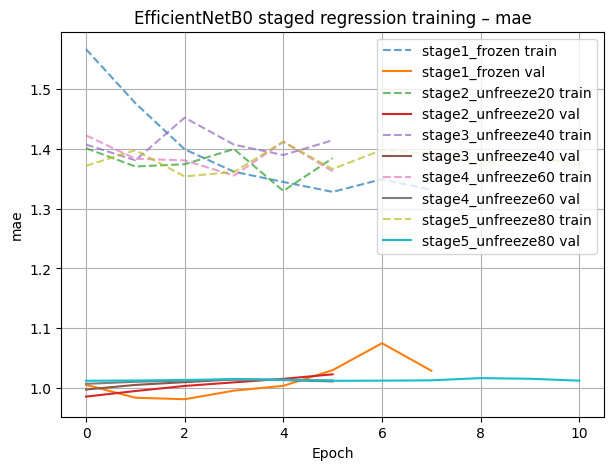

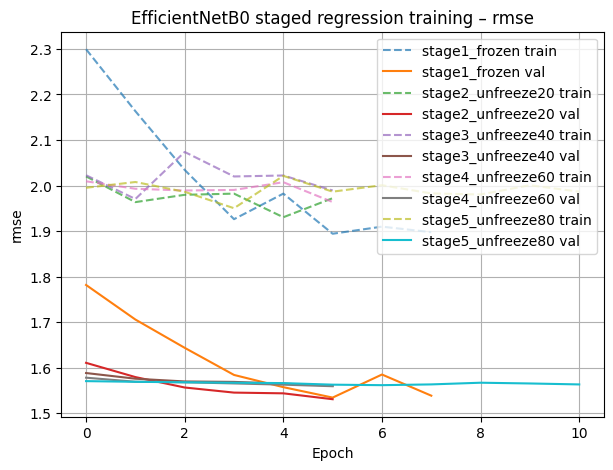

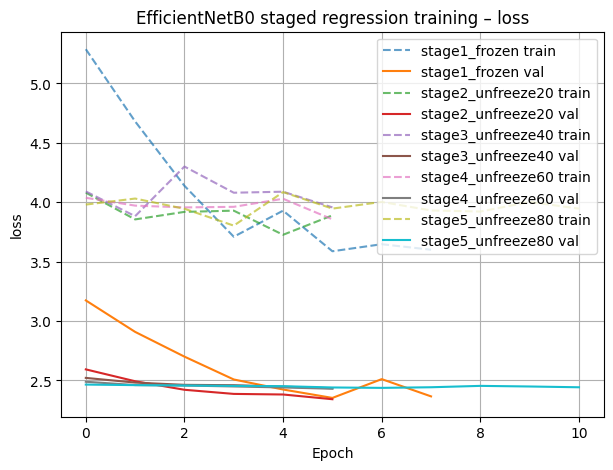

In [15]:
def plot_stage_histories(histories_dict: dict[str, dict[str, list[float]]], metric: str = "mae") -> None:
    plt.figure(figsize=(7, 5))

    for name, history in histories_dict.items():
        if metric in history:
            plt.plot(history[metric], linestyle="--", alpha=0.7, label=f"{name} train")
        if f"val_{metric}" in history:
            plt.plot(history[f"val_{metric}"], label=f"{name} val")

    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(f"EfficientNetB0 staged regression training – {metric}")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_stage_histories(stage_histories, metric="mae")
plot_stage_histories(stage_histories, metric="rmse")
plot_stage_histories(stage_histories, metric="loss")

The training curves show that training MAE and RMSE are consistently higher than validation MAE and RMSE. This does not necessarily indicate a problem, because the training pipeline may include stronger augmentation and dropout effects, while validation is evaluated more deterministically.

Stage 1 shows the clearest improvement in validation RMSE and loss. Later stages mainly make small adjustments around the same validation range. This supports the idea that the frozen EfficientNetB0 feature extractor already provides most of the useful representation.

Compared with the previous regression notebooks, the training curves are more promising in terms of RMSE/R² because the final test R² is no longer approximately zero. However, the absence of a clear MAE improvement over the baseline means that the model has not solved the regression task.


## 📉 14. Predicted vs true `target_SE`

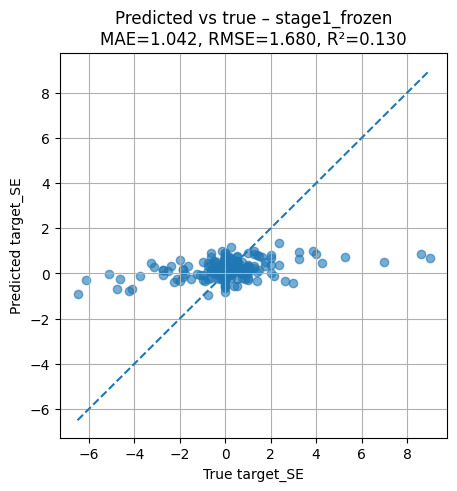

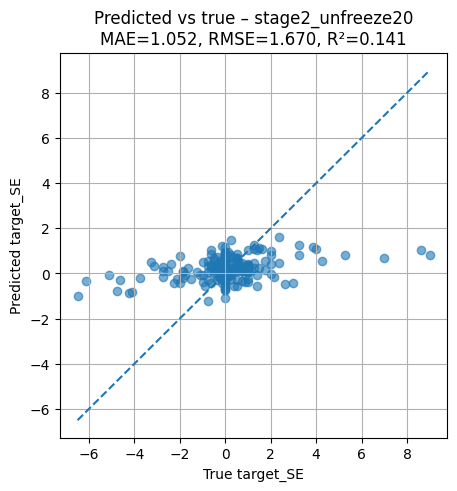

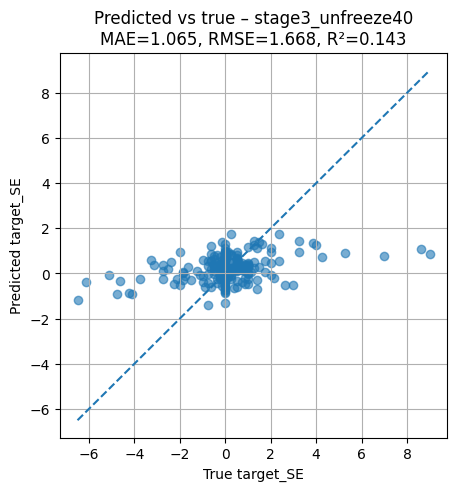

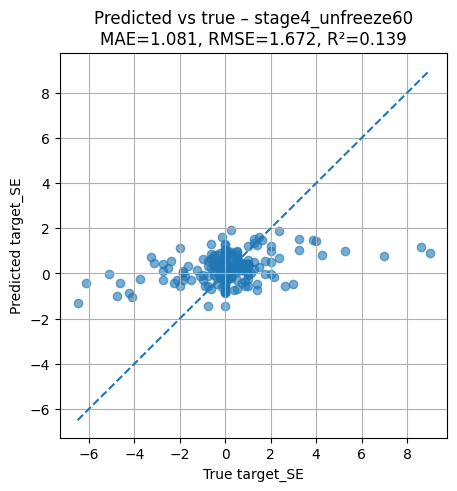

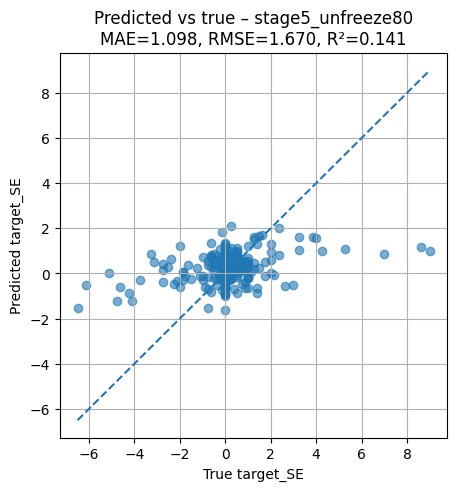

In [16]:
def plot_predictions_from_summaries(stage_summaries: list[dict[str, Any]]) -> None:
    for summary in stage_summaries:
        ev = summary["evaluation"]
        y_true = np.array(ev["y_true"], dtype=float)
        y_pred = np.array(ev["y_pred"], dtype=float)

        plt.figure(figsize=(5, 5))
        plt.scatter(y_true, y_pred, alpha=0.6)

        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())
        plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

        plt.xlabel("True target_SE")
        plt.ylabel("Predicted target_SE")
        plt.title(
            f"Predicted vs true – {summary['stage_name']}\n"
            f"MAE={ev['mae']:.3f}, RMSE={ev['rmse']:.3f}, R²={ev['r2']:.3f}"
        )
        plt.grid(True)
        plt.show()

plot_predictions_from_summaries(stage_summaries)

The predicted-vs-true plots show that the model predictions are still compressed around the central SE range. Most predictions remain between approximately **-1 D and +2 D**, even when the true SE values extend from around **-6.5 D to +9 D** in the test set.

This means the model no longer behaves exactly like a constant mean predictor, because the cloud of points has a weak positive trend and R² becomes positive. However, the model still underestimates the magnitude of extreme refractive errors.

Compared with the previous small CNN regression notebooks, this is a partial improvement. The earlier models predicted values extremely close to zero for almost all images and obtained R² values around zero. EfficientNetB0 shows some SE-related ordering, but the prediction range is still too narrow for accurate clinical estimation.


## 📊 15. Residual plots


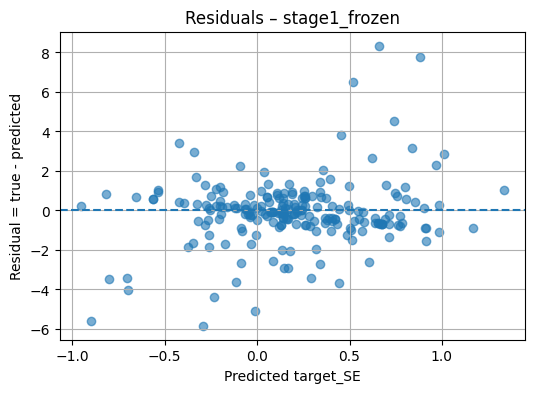

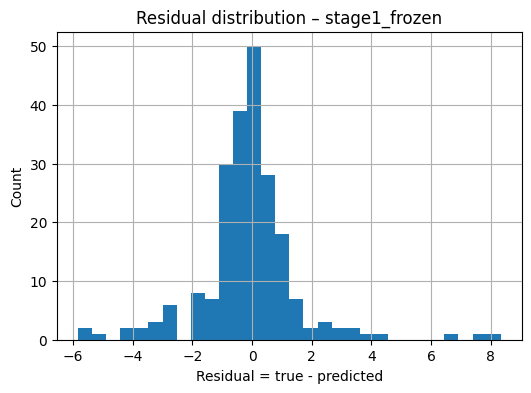

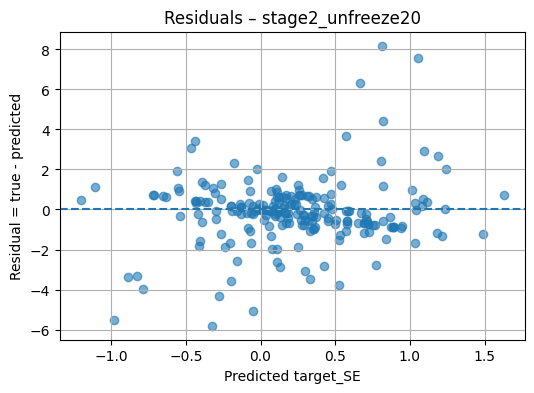

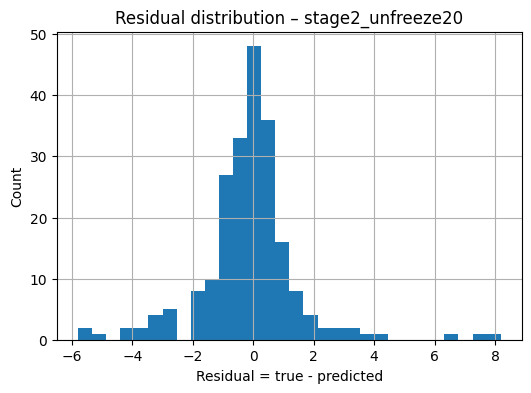

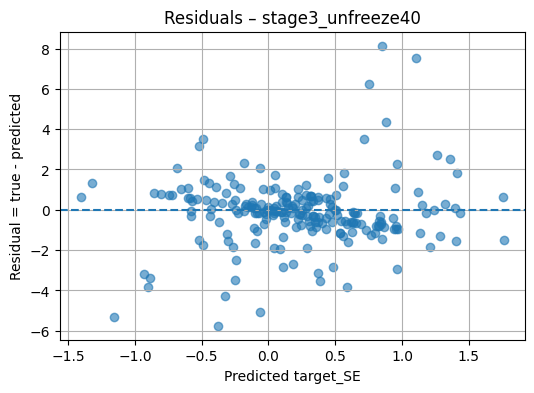

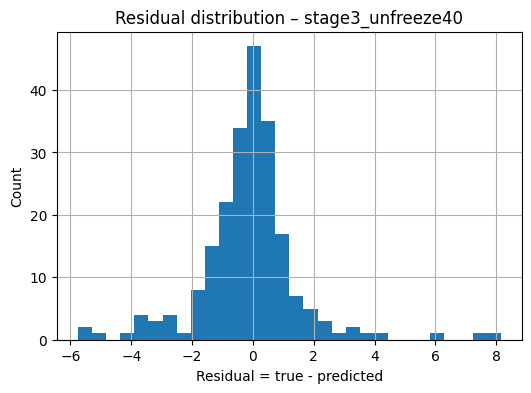

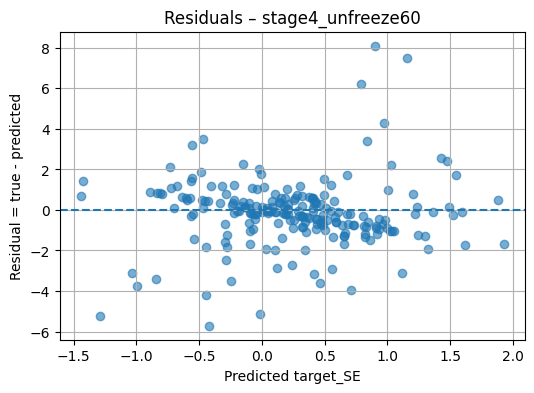

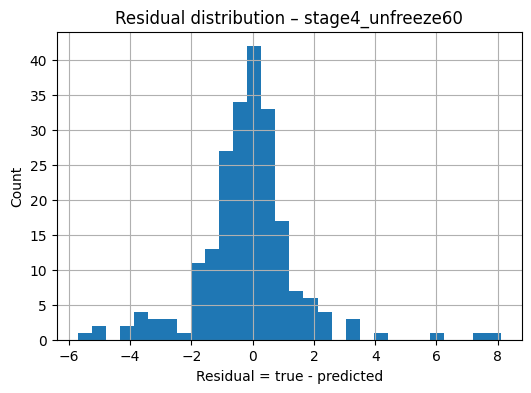

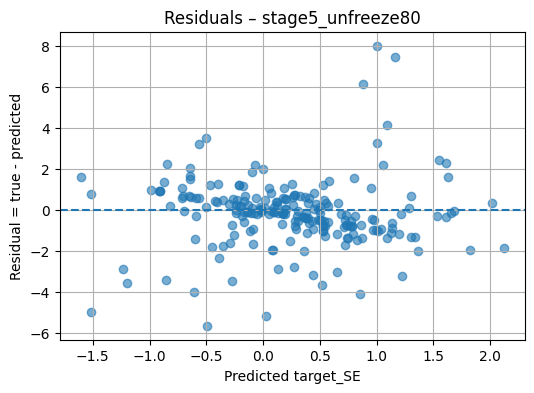

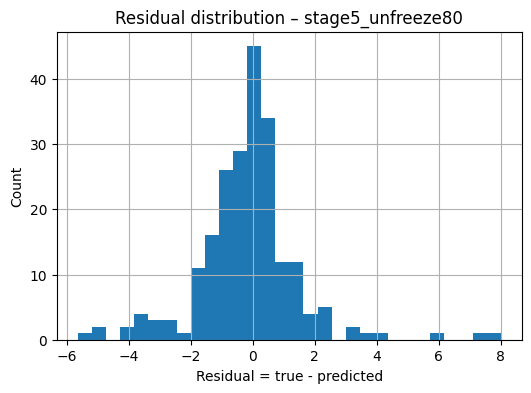

In [17]:
def plot_residuals_from_summaries(stage_summaries: list[dict[str, Any]]) -> None:
    for summary in stage_summaries:
        ev = summary["evaluation"]
        y_pred = np.array(ev["y_pred"], dtype=float)
        residuals = np.array(ev["residuals"], dtype=float)

        plt.figure(figsize=(6, 4))
        plt.scatter(y_pred, residuals, alpha=0.6)
        plt.axhline(0, linestyle="--")
        plt.xlabel("Predicted target_SE")
        plt.ylabel("Residual = true - predicted")
        plt.title(f"Residuals – {summary['stage_name']}")
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(6, 4))
        plt.hist(residuals, bins=30)
        plt.xlabel("Residual = true - predicted")
        plt.ylabel("Count")
        plt.title(f"Residual distribution – {summary['stage_name']}")
        plt.grid(True)
        plt.show()

plot_residuals_from_summaries(stage_summaries)

The residual plots confirm the same pattern seen in the predicted-vs-true figures. Errors are not random across the full SE range. For strongly negative or strongly positive SE values, the model tends to pull predictions back toward the centre of the distribution.

This behaviour is typical when the model learns the dominant central tendency of an imbalanced continuous target distribution but does not fully capture the extremes. As a result, RMSE improves compared with the baseline because the model captures some variance, but MAE remains limited because many central predictions are not sufficiently accurate to beat the mean predictor.

The residuals also explain why Stage 3 can be considered best by R², while Stage 1 remains best by MAE. Stage 3 slightly improves the variance explained, but this comes at the cost of a higher average absolute error.


## 📝 16. Results template


Short text skeleton that can be adapted for the TFG results section.


In [18]:
best_mae_row = results_df.sort_values("test_mae", ascending=True).iloc[0]
best_r2_row = results_df.sort_values("test_r2", ascending=False).iloc[0]

print("Best stage by MAE:")
print(best_mae_row[["stage_name", "test_mae", "test_rmse", "test_r2", "baseline_mae"]])

print("\nBest stage by R²:")
print(best_r2_row[["stage_name", "test_mae", "test_rmse", "test_r2", "baseline_r2"]])

Best stage by MAE:
stage_name      stage1_frozen
test_mae             1.042377
test_rmse            1.680329
test_r2              0.130474
baseline_mae         1.027415
Name: 0, dtype: object

Best stage by R²:
stage_name     stage3_unfreeze40
test_mae                1.064851
test_rmse               1.668446
test_r2                 0.142729
baseline_r2            -0.002601
Name: 2, dtype: object


-> Regresión: Stage 5 tiene mejor R2 y RMSE, pero S1 gana en MAE. De todas maneras, como ningún stage mejora el baseline en MAE, conviene no fijarse tanto en MAE.
Por tanto "gana" S5, que parece que encuentra más señal.

Best stage by MAE vs best stage by R²:

The notebook identifies **Stage 1** as the best stage by MAE and **Stage 3** as the best stage by R².

This is an important distinction. Stage 1 is the safest model if the priority is minimizing average absolute prediction error, but it does not beat the baseline MAE. Stage 3 is more interesting scientifically because it obtains the highest R² (**0.143**) and the lowest RMSE (**1.668 D**), indicating that it captures more SE-related variance than the previous regression models.

For the TFG discussion, this result should not be presented as a complete regression success. A more accurate interpretation is that **EfficientNetB0 transfer learning is the first regression model that shows clear positive R²**, but its MAE remains too close to or worse than the baseline to be considered a clinically reliable SE estimator.


### Final conclusions:

This notebook evaluates **EfficientNetB0 transfer learning for SE regression** using the **FullPreproc** dataset and a five-stage fine-tuning strategy.

The most important result is that EfficientNetB0 performs better than previous regression models in terms of **R² and RMSE**, but not in terms of **MAE**. The best MAE is obtained by **Stage 1**, with **test MAE = 1.042 D**, while the baseline mean predictor obtains **MAE = 1.027 D**. Therefore, the model does not improve the average absolute error over the baseline.

However, the best R² is obtained by **Stage 3**, with **R² = 0.143** and **RMSE = 1.668 D**. This is clearly better than the baseline, which has **R² ≈ -0.003** and **RMSE = 1.804 D**. It is also better than the previous small CNN regression notebooks, where R² remained approximately zero, and better than the ResNet regression model, which obtained a negative R².

This means that transfer learning does extract some SE-related signal from the retinal images. Nevertheless, the predicted-vs-true plots show that predictions remain compressed around the central range and fail to reproduce the most extreme SE values. Therefore, the model partially improves variance explanation but still does not provide accurate continuous SE estimation.

Compared with the previous EfficientNetB0 classification notebook, the contrast is clear: transfer learning helped classification more strongly than regression. In classification, EfficientNetB0 improved AUC and AP compared with small CNNs and ResNet models. In regression, EfficientNetB0 improves R² but still struggles to beat the MAE baseline. This supports the broader conclusion that **binary myopia classification is more feasible than direct SE regression** with the current dataset and image-only approach.

The staged fine-tuning strategy also shows limited benefit. Stage 1 already provides the best MAE, while unfreezing more layers only slightly improves R² and RMSE. Therefore, extensive fine-tuning does not clearly justify its additional computational cost unless the discussion prioritizes variance explanation over absolute error.

Overall, this notebook should be interpreted as a **partial regression improvement**, not as a final successful regression model. EfficientNetB0 is the first regression approach that shows meaningful positive R², but its MAE and compressed prediction range indicate that further work is needed before SE prediction can be considered reliable.


All in all: 

EfficientNetB0 transfer learning improved SE regression compared with the previous CNN and ResNet models in terms of R² and RMSE. The best stage by R² was Stage 3, reaching R² = 0.143 and RMSE = 1.668 D, clearly better than the mean baseline and previous regression models with R² ≈ 0. However, the best MAE was obtained by Stage 1 with 1.042 D, still worse than the baseline MAE of 1.027 D. Therefore, the model captures some SE-related signal but does not yet provide accurate continuous SE prediction. This reinforces the idea that classification is currently more robust than regression for this dataset.
